In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Clean Coinmetrics

In [ ]:
# read data
df = pd.read_csv("../data/Coin Metrics/coinmetrics_btc.csv")
df["time"] = pd.to_datetime(df["time"])
df

,time,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,...,ReferenceRateETH,ReferenceRateEUR,ReferenceRateUSD,SplyCur,SplyExNtv,SplyExUSD,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d
0,2009-01-03,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.000000,...,NaN,NaN,NaN,0.000000e+00,0.000000e+00,NaN,NaN,0.0,0.0,NaN
1,2009-01-04,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.000000,...,NaN,NaN,NaN,0.000000e+00,0.000000e+00,NaN,NaN,0.0,0.0,NaN
2,2009-01-05,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.000000,...,NaN,NaN,NaN,0.000000e+00,0.000000e+00,NaN,NaN,0.0,0.0,NaN
3,2009-01-06,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.000000,...,NaN,NaN,NaN,0.000000e+00,0.000000e+00,NaN,NaN,0.0,0.0,NaN
4,2009-01-07,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.000000,...,NaN,NaN,NaN,0.000000e+00,0.000000e+00,NaN,NaN,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6216,2026-01-10,608784.0,55908713.0,1.768101e+09,1.768101e+09,162.0,1.610013,1.805781e+12,1.805753e+12,2.085347,...,29.348301,77853.756824,90539.603229,1.997410e+07,2.480800e+06,2.242796e+11,2.082608e+07,492984.0,1049925.0,2.998463e+09
6217,2026-01-11,536405.0,55924280.0,1.768187e+09,1.768187e+09,122.0,1.615856,1.812029e+12,1.812010e+12,1.915416,...,29.333069,77790.505193,90406.142411,1.997448e+07,2.484575e+06,2.253937e+11,2.082618e+07,289219.0,572262.0,4.399753e+09
6218,2026-01-12,638422.0,55917951.0,1.768275e+09,1.768275e+09,142.0,1.623512,1.820538e+12,1.820513e+12,2.322577,...,29.145653,78047.851052,90717.206315,1.997493e+07,2.482087e+06,2.262203e+11,2.082629e+07,405384.0,845895.0,1.344799e+10
6219,2026-01-13,701272.0,55891967.0,1.768360e+09,1.768360e+09,135.0,1.695646,1.903741e+12,1.903718e+12,3.019455,...,29.485280,78130.277588,91141.149849,1.997535e+07,2.474529e+06,2.358337e+11,2.082639e+07,340763.0,731900.0,1.805277e+10


In [ ]:
# test the commit
start = "2018-01-01"
end = "2025-12-31"
df = df[(df["time"] >= start) & (df["time"] <= end)].copy()
# sort and set the index
df = df.sort_values("time").set_index("time")

In [6]:
# check缺失日期
all_days = pd.date_range(start, end, freq="D")
missing_days = all_days.difference(df.index)
len(missing_days)

0

In [7]:
# rename 价格列
df = df.rename(columns={"PriceUSD": "PriceUSD_coinmetrics"})

In [8]:
# 6) create metrics

px = df["PriceUSD_coinmetrics"]

df["ret_1d"] = px.pct_change()
df["logret_1d"] = np.log(px).diff()

# 年化波动率
df["vol_30d"] = df["logret_1d"].rolling(30).std() * np.sqrt(365)

# 200日均线
df["ma_200"] = px.rolling(200).mean()
df["price_vs_ma200"] = px / df["ma_200"] - 1

# 回撤
rolling_max = px.cummax()
df["drawdown"] = px / rolling_max - 1


In [9]:
df

,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,FlowInExNtv,...,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d,ret_1d,logret_1d,vol_30d,ma_200,price_vs_ma200,drawdown
time,,,,,,,,,,,,,,,,,,,,,
2018-01-01,972783.0,26829117.0,1.614337e+09,1.614337e+09,156.0,2.694235,2.258877e+11,NaN,477.225170,36000.622080,...,2.027413e+07,241625.0,677625.0,4.860752e+09,NaN,NaN,NaN,NaN,NaN,0.000000
2018-01-02,1142721.0,26909375.0,1.614337e+09,1.614337e+09,171.0,2.925443,2.475552e+11,NaN,649.878138,65831.310897,...,2.027467e+07,343664.0,960051.0,8.485368e+09,0.095782,0.091468,NaN,NaN,NaN,0.000000
2018-01-03,1130917.0,27133378.0,1.614337e+09,1.614337e+09,157.0,2.960267,2.518793e+11,NaN,750.020447,56969.474964,...,2.027516e+07,396942.0,1049679.0,8.041486e+09,0.017348,0.017200,NaN,NaN,NaN,0.000000
2018-01-04,1253986.0,27415056.0,1.614337e+09,1.614337e+09,168.0,2.944022,2.529181e+11,NaN,777.017867,77816.063305,...,2.027568e+07,424762.0,1191394.0,1.138178e+10,0.003998,0.003990,NaN,NaN,NaN,0.000000
2018-01-05,1069525.0,27645350.0,1.614337e+09,1.614337e+09,143.0,3.261964,2.852872e+11,NaN,704.313737,72765.218396,...,2.027613e+07,339441.0,1002989.0,1.288165e+10,0.127863,0.120324,NaN,NaN,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,569638.0,55728140.0,1.766890e+09,1.766890e+09,136.0,1.561130,1.751089e+12,1.751067e+12,2.079782,9435.308947,...,2.082452e+07,475008.0,1027864.0,3.260594e+09,0.004129,0.004121,0.378190,107387.763565,-0.183376,-0.297450
2025-12-28,572908.0,55752466.0,1.766977e+09,1.766977e+09,155.0,1.562371,1.752174e+12,1.752146e+12,2.155405,9847.439706,...,2.082464e+07,540696.0,1155370.0,4.029677e+09,0.000596,0.000595,0.378143,107283.272883,-0.182094,-0.297032
2025-12-29,693511.0,55767043.0,1.767065e+09,1.767065e+09,154.0,1.551844,1.739953e+12,1.739927e+12,2.806141,32455.348312,...,2.082476e+07,548253.0,1175491.0,1.586258e+10,-0.006999,-0.007024,0.378686,107188.945506,-0.187104,-0.301952


# 2. EDA

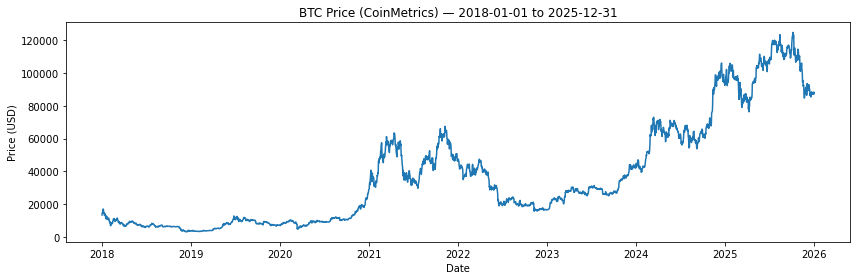

In [10]:
# 价格走势
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["PriceUSD_coinmetrics"])
plt.title("BTC Price (CoinMetrics) — 2018-01-01 to 2025-12-31")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()



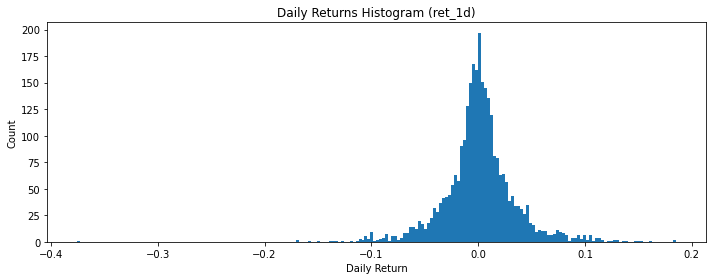

In [11]:
# 日收益率分布
rets = df["ret_1d"].dropna()
plt.figure(figsize=(10, 4))
plt.hist(rets, bins=200)
plt.title("Daily Returns Histogram (ret_1d)")
plt.xlabel("Daily Return")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


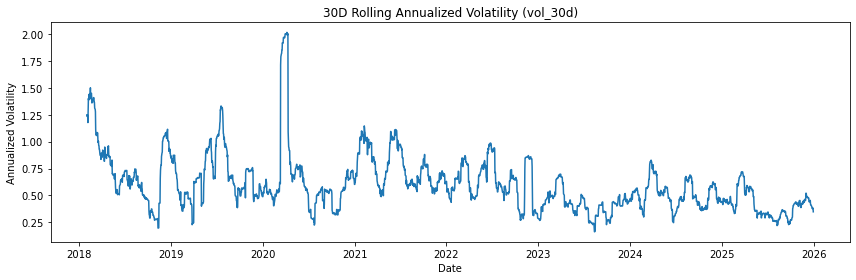

In [12]:
# 30日滚动年化波动率
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["vol_30d"])
plt.title("30D Rolling Annualized Volatility (vol_30d)")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.tight_layout()
plt.show()



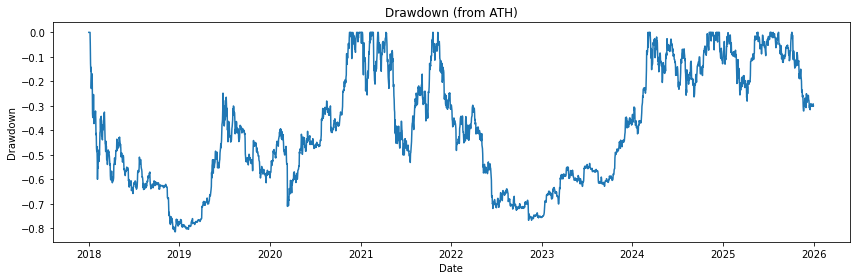

In [13]:
# 回撤曲线
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["drawdown"])
plt.title("Drawdown (from ATH)")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.tight_layout()
plt.show()